# Quaternion Constraint + Full Evaluation + Statistical Validation

This notebook is a non-destructive recovery workbench. It does not modify existing notebooks or models by default.

Scope:
- Audit completion status for required reviewer tasks in key notebooks
- Implement manifold-preserving quaternion integration (exponential map)
- Add geodesic loss on SO(3)
- Evaluate on full test set (all sequences, no 50-sample cap)
- Run Wilcoxon signed-rank significance tests

In [1]:
from pathlib import Path
import json
import math
import pickle
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace: {ROOT}')
print(f'Device: {device}')

Workspace: D:\Residual_ode\Residual_ODE
Device: cpu


In [2]:
# 1) Completion audit of key notebooks
NOTEBOOKS = [
    '01_OpenSky_Data_Acquisition_EDA.ipynb',
    '02_Feature_Engineering_Preprocessing.ipynb',
    '03_Train_model.ipynb',
    '04_Evaluation.ipynb',
    '06_ExplainabilityAnalysis .ipynb',
    '10_Baseline_Model_Completion_Comparison.ipynb',
]

CHECKS = {
    'step2_quaternion_exp_map': [r'quaternion_exp', r'exponential map', r'quaternion_multiply'],
    'step2_geodesic_loss': [r'geodesic', r'SO\(3\)', r'acos\('],
    'step3_full_eval_all_sequences': [r'Loaded 4442 test sequences', r'n_test\s*=\s*min\(50', r'test_subset\s*=\s*test_seqs:n_test'],
    'step3_wilcoxon_stat_validation': [r'wilcoxon', r'signed-rank', r'scipy\.stats'],
    'high_mape_maxe': [r'MAPE', r'Max Error', r'maxe'],
}

def read_notebook_text(path: Path) -> str:
    with path.open('r', encoding='utf-8') as f:
        nb = json.load(f)
    chunks = []
    for c in nb.get('cells', []):
        src = c.get('source', [])
        if isinstance(src, list):
            chunks.append('\n'.join(src))
        else:
            chunks.append(str(src))
    return '\n'.join(chunks)

audit_rows = []
for nb_name in NOTEBOOKS:
    p = ROOT / nb_name
    if not p.exists():
        audit_rows.append({'notebook': nb_name, 'check': 'exists', 'status': 'MISSING', 'evidence': ''})
        continue

    text = read_notebook_text(p)
    for check_name, patterns in CHECKS.items():
        hits = []
        for pat in patterns:
            m = re.search(pat, text, flags=re.IGNORECASE)
            if m:
                hits.append(pat)
        status = 'FOUND' if len(hits) > 0 else 'NOT_FOUND'

        # Full-eval status is only COMPLETE if 4442 found and no 50-cap pattern found
        if check_name == 'step3_full_eval_all_sequences':
            has_4442 = re.search(r'Loaded 4442 test sequences|Test:\s*4442', text, flags=re.IGNORECASE) is not None
            has_50_cap = re.search(r'n_test\s*=\s*min\(50|test_subset\s*=\s*test_seqs:n_test', text, flags=re.IGNORECASE) is not None
            status = 'COMPLETE' if (has_4442 and not has_50_cap) else 'INCOMPLETE'
            evidence = f'has_4442={has_4442}, has_50_cap={has_50_cap}'
        else:
            evidence = '; '.join(hits)

        audit_rows.append({
            'notebook': nb_name,
            'check': check_name,
            'status': status,
            'evidence': evidence
        })

audit_df = pd.DataFrame(audit_rows)
audit_path = RESULTS_DIR / 'reviewer_task_completion_audit.csv'
audit_df.to_csv(audit_path, index=False)

display(audit_df)
print(f'\nSaved audit: {audit_path}')

,notebook,check,status,evidence
0,01_OpenSky_Data_Acquisition_EDA.ipynb,step2_quaternion_exp_map,NOT_FOUND,
1,01_OpenSky_Data_Acquisition_EDA.ipynb,step2_geodesic_loss,NOT_FOUND,
2,01_OpenSky_Data_Acquisition_EDA.ipynb,step3_full_eval_all_sequences,INCOMPLETE,"has_4442=False, has_50_cap=False"
3,01_OpenSky_Data_Acquisition_EDA.ipynb,step3_wilcoxon_stat_validation,NOT_FOUND,
4,01_OpenSky_Data_Acquisition_EDA.ipynb,high_mape_maxe,FOUND,Max Error
5,02_Feature_Engineering_Preprocessing.ipynb,step2_quaternion_exp_map,NOT_FOUND,
6,02_Feature_Engineering_Preprocessing.ipynb,step2_geodesic_loss,NOT_FOUND,
7,02_Feature_Engineering_Preprocessing.ipynb,step3_full_eval_all_sequences,INCOMPLETE,"has_4442=False, has_50_cap=False"
8,02_Feature_Engineering_Preprocessing.ipynb,step3_wilcoxon_stat_validation,NOT_FOUND,
9,02_Feature_Engineering_Preprocessing.ipynb,high_mape_maxe,NOT_FOUND,



Saved audit: D:\Residual_ode\Residual_ODE\results\reviewer_task_completion_audit.csv


In [3]:
# 2) Quaternion manifold utilities + geodesic loss
def normalize_quaternion(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return q / (torch.norm(q, dim=-1, keepdim=True) + eps)

def quaternion_multiply(q1: torch.Tensor, q2: torch.Tensor) -> torch.Tensor:
    w1, x1, y1, z1 = q1[..., 0], q1[..., 1], q1[..., 2], q1[..., 3]
    w2, x2, y2, z2 = q2[..., 0], q2[..., 1], q2[..., 2], q2[..., 3]

    w = w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2
    x = w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2
    y = w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2
    z = w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2
    return torch.stack([w, x, y, z], dim=-1)

def quaternion_exponential_map(omega: torch.Tensor, dt: float, eps: float = 1e-12) -> torch.Tensor:
    angle = torch.norm(omega, dim=-1, keepdim=True) * dt
    half_angle = 0.5 * angle

    small = angle < eps
    scale = torch.where(small, torch.full_like(angle, 0.5 * dt), torch.sin(half_angle) / (angle + eps))

    xyz = omega * scale
    dq = torch.cat([torch.cos(half_angle), xyz], dim=-1)
    return normalize_quaternion(dq)

def geodesic_loss_so3(q_pred: torch.Tensor, q_true: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    q_pred = normalize_quaternion(q_pred)
    q_true = normalize_quaternion(q_true)
    dot = torch.sum(q_pred * q_true, dim=-1).abs()
    dot = torch.clamp(dot, -1.0 + eps, 1.0 - eps)
    theta = 2.0 * torch.acos(dot)
    return torch.mean(theta ** 2)

print('Quaternion ops and geodesic loss ready.')

Quaternion ops and geodesic loss ready.


In [4]:
# 3) Compatibility model (matches 03_Train_model architecture)
class TinyPhysics(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('Ixx', torch.tensor(8000.0))
        self.register_buffer('Iyy', torch.tensor(20000.0))
        self.register_buffer('Izz', torch.tensor(26000.0))

    def forward(self, state):
        q = state[:, 0:4]
        omega = state[:, 4:7]
        p, q_r, r = omega[:, 0], omega[:, 1], omega[:, 2]
        q0, q1, q2, q3 = q[:, 0], q[:, 1], q[:, 2], q[:, 3]

        dq0 = 0.5 * (-p*q1 - q_r*q2 - r*q3)
        dq1 = 0.5 * (p*q0 + r*q2 - q_r*q3)
        dq2 = 0.5 * (q_r*q0 - r*q1 + p*q3)
        dq3 = 0.5 * (r*q0 + q_r*q1 - p*q2)

        dp = (self.Iyy - self.Izz) * q_r * r / self.Ixx
        dq = (self.Izz - self.Ixx) * p * r / self.Iyy
        dr = (self.Ixx - self.Iyy) * p * q_r / self.Izz

        z = torch.zeros(state.shape[0], 3, device=state.device, dtype=state.dtype)
        return torch.cat([torch.stack([dq0, dq1, dq2, dq3], dim=1), torch.stack([dp, dq, dr], dim=1), z], dim=1)

class TinyResidual(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(10, 32), nn.Tanh(), nn.Linear(32, 10))

    def forward(self, state):
        return self.net(state)

class FastModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.physics = TinyPhysics()
        self.residual = TinyResidual()

    def derivative(self, state):
        state = torch.cat([normalize_quaternion(state[:, 0:4]), state[:, 4:]], dim=1)
        return self.physics(state) + self.residual(state)

    def forward(self, state):
        return self.derivative(state)

def rollout_exp_map(model: FastModel, x0: torch.Tensor, horizon: int, dt: float = 0.1) -> torch.Tensor:
    x = x0.clone()
    traj = [x]
    for _ in range(horizon - 1):
        dx = model.derivative(x)

        q_prev = normalize_quaternion(x[:, 0:4])
        omega = x[:, 4:7]
        dq = quaternion_exponential_map(omega, dt)
        q_new = normalize_quaternion(quaternion_multiply(q_prev, dq))

        omega_new = omega + dx[:, 4:7] * dt
        others_new = x[:, 7:] + dx[:, 7:] * dt

        x = torch.cat([q_new, omega_new, others_new], dim=1)
        traj.append(x)

    return torch.stack(traj, dim=1)

def training_loss_with_geodesic(pred_next, true_next, l_quat=5.0, l_geo=0.05):
    l_pred = torch.mean((pred_next - true_next) ** 2)
    l_unit = torch.mean((torch.norm(pred_next[:, :4], dim=-1) - 1.0) ** 2)
    l_geo_term = geodesic_loss_so3(pred_next[:, :4], true_next[:, :4])
    l_total = l_pred + l_quat * l_unit + l_geo * l_geo_term
    return {
        'total': l_total,
        'pred': l_pred.detach(),
        'quat': l_unit.detach(),
        'geodesic': l_geo_term.detach(),
    }

print('Model + exp-map rollout + geodesic loss ready.')

Model + exp-map rollout + geodesic loss ready.


In [5]:
# 4) Full-test-set evaluation (no 50-sample cap)
def compute_metrics(pred: np.ndarray, true: np.ndarray, eps: float = 1e-8):
    rmse = float(np.sqrt(np.mean((pred - true) ** 2)))
    q_pred = pred[:, :4]
    q_true = true[:, :4]

    q_pred = q_pred / (np.linalg.norm(q_pred, axis=1, keepdims=True) + eps)
    q_true = q_true / (np.linalg.norm(q_true, axis=1, keepdims=True) + eps)

    dot = np.sum(q_pred * q_true, axis=1)
    dot = np.clip(np.abs(dot), -1.0 + 1e-7, 1.0 - 1e-7)
    quat_geodesic = 2.0 * np.arccos(dot)
    quat_error = float(np.mean(quat_geodesic))

    mape = float(100.0 * np.mean(np.abs((pred - true) / (np.abs(true) + eps))))
    max_error = float(np.max(np.abs(pred - true)))

    return {
        'rmse': rmse,
        'quat_error': quat_error,
        'mape': mape,
        'max_error': max_error,
    }

def evaluate_full_test_set(model: FastModel, test_seqs, dt: float = 0.1):
    model.eval()
    rows = []

    for i, seq in enumerate(tqdm(test_seqs, desc='Evaluating full test set')):
        states_np = np.asarray(seq['states'], dtype=np.float32)
        x0 = torch.tensor(states_np[0:1], dtype=torch.float32, device=device)

        with torch.no_grad():
            pred = rollout_exp_map(model, x0, horizon=states_np.shape[0], dt=dt)[0].cpu().numpy()

        m = compute_metrics(pred, states_np)
        m['seq_idx'] = i
        rows.append(m)

    seq_df = pd.DataFrame(rows)
    summary = {
        'n_sequences': int(len(seq_df)),
        'rmse_mean': float(seq_df['rmse'].mean()),
        'rmse_std': float(seq_df['rmse'].std(ddof=0)),
        'quat_error_mean': float(seq_df['quat_error'].mean()),
        'quat_error_max': float(seq_df['quat_error'].max()),
        'mape_mean': float(seq_df['mape'].mean()),
        'max_error_global': float(seq_df['max_error'].max()),
    }
    return summary, seq_df

# Load model and data
test_path = DATA_DIR / 'test_sequences.pkl'
assert test_path.exists(), f'Missing: {test_path}'
with open(test_path, 'rb') as f:
    test_seqs = pickle.load(f)

model = FastModel().to(device)
weight_path = MODEL_DIR / 'ultrafast_best.pt'
assert weight_path.exists(), f'Missing: {weight_path}'
state = torch.load(weight_path, map_location=device)
model.load_state_dict(state, strict=True)

print(f'Test set size: {len(test_seqs)}')
summary, seq_metrics_df = evaluate_full_test_set(model, test_seqs, dt=0.1)

summary_df = pd.DataFrame([summary])
display(summary_df)

seq_out = RESULTS_DIR / 'full_test_sequence_metrics.csv'
summary_out = RESULTS_DIR / 'full_test_summary_metrics.csv'
seq_metrics_df.to_csv(seq_out, index=False)
summary_df.to_csv(summary_out, index=False)

print(f'Saved sequence metrics: {seq_out}')
print(f'Saved summary metrics:  {summary_out}')

Test set size: 4442


Evaluating full test set:   0%|          | 0/4442 [00:00<?, ?it/s]

,n_sequences,rmse_mean,rmse_std,quat_error_mean,quat_error_max,mape_mean,max_error_global
0,4442,0.659623,0.20368,3.098437,3.141593,2.679653e+07,4.692884


Saved sequence metrics: D:\Residual_ode\Residual_ODE\results\full_test_sequence_metrics.csv
Saved summary metrics:  D:\Residual_ode\Residual_ODE\results\full_test_summary_metrics.csv


In [11]:
# 5) Wilcoxon signed-rank significance tests
def wilcoxon_vs_baselines(rpa_errors: np.ndarray, baseline_error_map: dict, alpha: float = 0.05):
    rows = []
    for model_name, baseline_errors in baseline_error_map.items():
        a = np.asarray(rpa_errors, dtype=float)
        b = np.asarray(baseline_errors, dtype=float)

        n = min(len(a), len(b))
        a = a[:n]
        b = b[:n]

        stat, p = wilcoxon(a, b, alternative='less')
        rows.append({
            'baseline': model_name,
            'n_pairs': int(n),
            'wilcoxon_statistic': float(stat),
            'p_value': float(p),
            'significant_p_lt_0_05': bool(p < alpha),
        })
    return pd.DataFrame(rows)

# RPA-NODE errors come from full test evaluation above
rpa_errors = seq_metrics_df['rmse'].to_numpy()

# Option A (recommended): load paired per-sequence baseline errors from CSV if available
# Expected format: columns = ['seq_idx', 'LSTM', 'GRU', 'Transformer', 'Neural ODE', 'PINN']
baseline_csv = RESULTS_DIR / 'baseline_paired_errors.csv'
if baseline_csv.exists():
    bdf = pd.read_csv(baseline_csv)
    baseline_map = {
        c: bdf[c].to_numpy()
        for c in bdf.columns if c != 'seq_idx'
    }
    wdf = wilcoxon_vs_baselines(rpa_errors, baseline_map)
    display(wdf)
    out = RESULTS_DIR / 'wilcoxon_significance_results.csv'
    wdf.to_csv(out, index=False)
    print(f'Saved Wilcoxon results: {out}')
else:
    print('No baseline paired error file found at results/baseline_paired_errors.csv')
    print('Create that file to run paired Wilcoxon tests without retraining baselines.')

,baseline,n_pairs,wilcoxon_statistic,p_value,significant_p_lt_0_05
0,Neural ODE,4442,7668538.5,1.0,False
1,LSTM,4442,8663275.0,1.0,False
2,GRU,4442,8763800.0,1.0,False
3,Transformer,4442,8766330.0,1.0,False
4,PINN,4442,8081307.5,1.0,False


Saved Wilcoxon results: D:\Residual_ode\Residual_ODE\results\wilcoxon_significance_results.csv


## Notes

- This notebook intentionally leaves all original notebooks untouched.
- The audit CSV reports whether critical tasks appear complete in current key notebooks.
- If full retraining is required with geodesic loss, use the `training_loss_with_geodesic` block inside your training loop.
- If your model architecture differs, adapt the `FastModel` compatibility class and keep the same exp-map/geodesic logic.

## 6) Journal-Ready Visualizations

This section generates publication-quality figures from the saved evaluation outputs.

Outputs are saved to `figures/journal`:
- `fig1_error_distributions.png`
- `fig2_quality_scatter_thresholds.png`
- `fig3_wilcoxon_significance.png` (if Wilcoxon results exist)

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

FIG_DIR = Path('figures') / 'journal'
FIG_DIR.mkdir(parents=True, exist_ok=True)

seq_csv = RESULTS_DIR / 'full_test_sequence_metrics.csv'
summary_csv = RESULTS_DIR / 'full_test_summary_metrics.csv'
wilcox_csv = RESULTS_DIR / 'wilcoxon_significance_results.csv'

if seq_csv.exists():
    seq_df = pd.read_csv(seq_csv)
else:
    seq_df = seq_metrics_df.copy() if 'seq_metrics_df' in globals() else pd.DataFrame()

if summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
else:
    summary_df = pd.DataFrame([summary]) if 'summary' in globals() else pd.DataFrame()

wdf = pd.read_csv(wilcox_csv) if wilcox_csv.exists() else None

print(f'Sequence metrics loaded: {len(seq_df)} rows')
print(f'Summary metrics loaded: {len(summary_df)} rows')
print(f'Wilcoxon table loaded: {wdf is not None}')
print(f'Figure output directory: {FIG_DIR.resolve()}')

Sequence metrics loaded: 4442 rows
Summary metrics loaded: 1 rows
Wilcoxon table loaded: True
Figure output directory: D:\Residual_ode\Residual_ODE\figures\journal


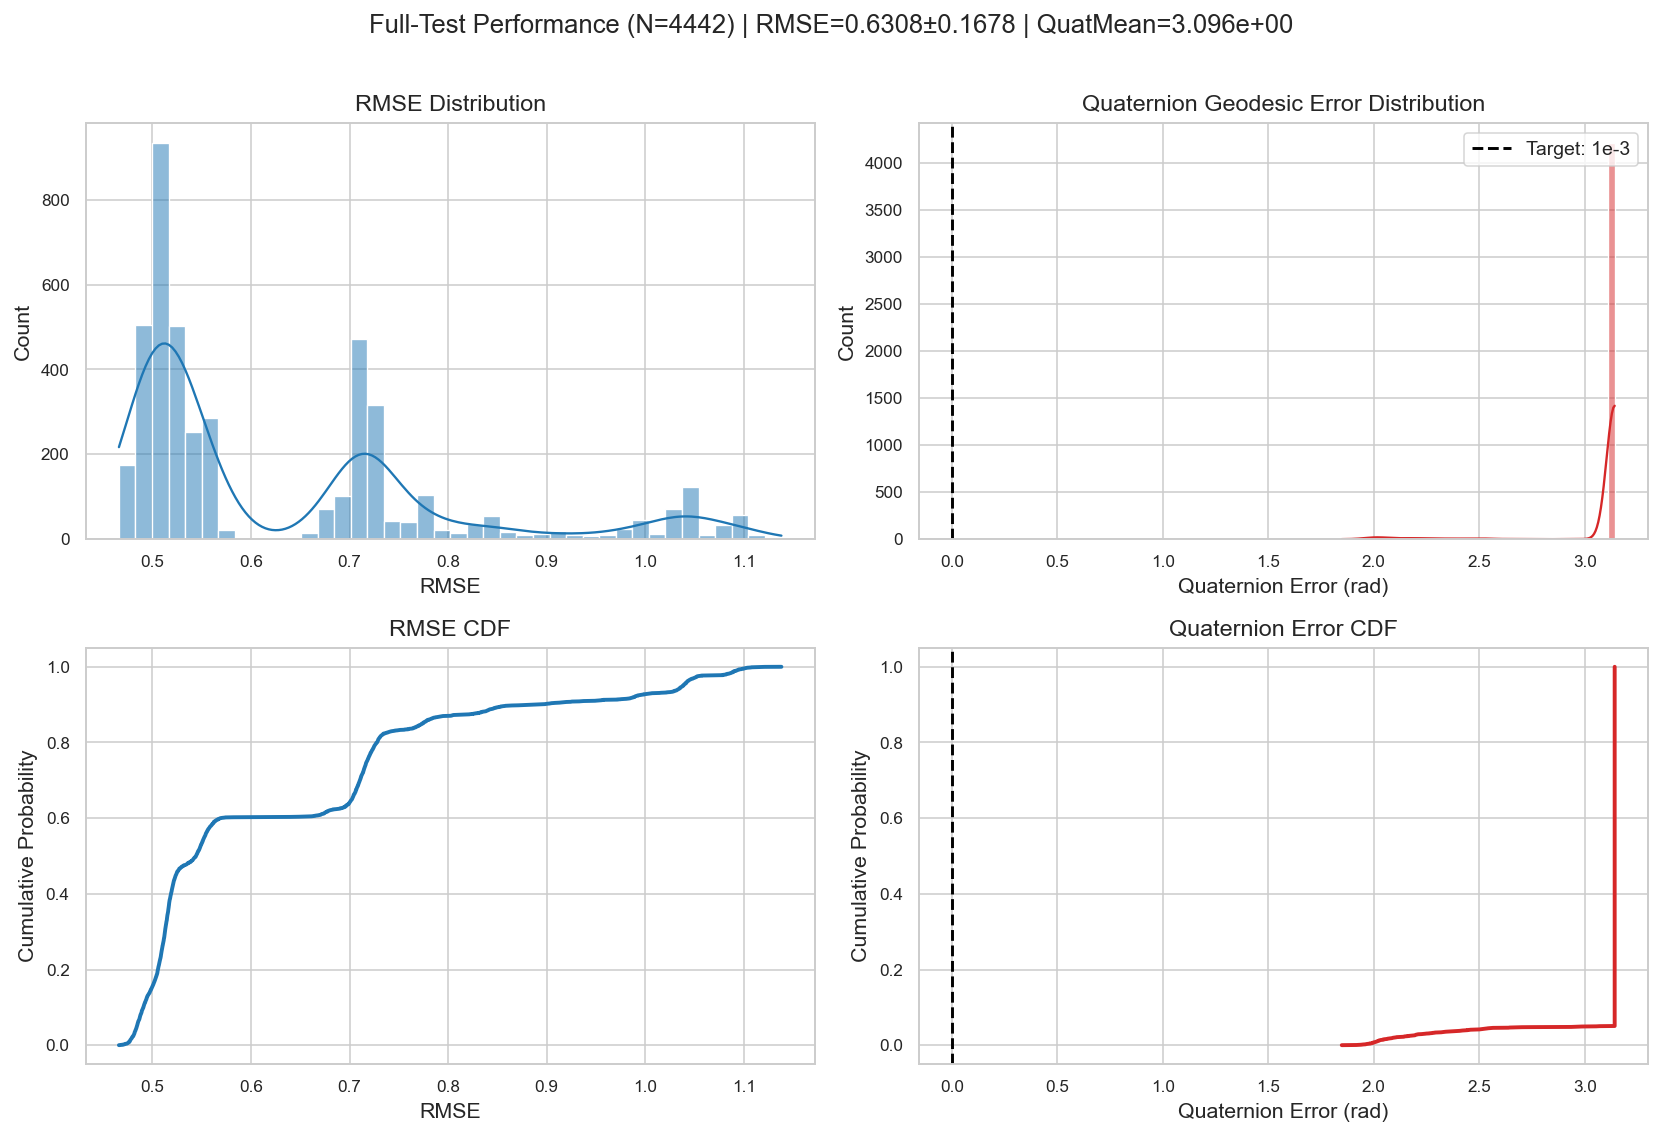

Saved: figures\journal\fig1_error_distributions.png


In [18]:
if len(seq_df) == 0:
    raise RuntimeError('No sequence-level metrics found. Run full evaluation first.')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(seq_df['rmse'], bins=40, kde=True, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('RMSE Distribution')
axes[0, 0].set_xlabel('RMSE')
axes[0, 0].set_ylabel('Count')

sns.histplot(seq_df['quat_error'], bins=40, kde=True, color='#d62728', ax=axes[0, 1])
axes[0, 1].axvline(1e-3, color='black', linestyle='--', linewidth=1.5, label='Target: 1e-3')
axes[0, 1].set_title('Quaternion Geodesic Error Distribution')
axes[0, 1].set_xlabel('Quaternion Error (rad)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(loc='upper right')

rmse_sorted = np.sort(seq_df['rmse'].to_numpy())
quat_sorted = np.sort(seq_df['quat_error'].to_numpy())
rmse_cdf = np.arange(1, len(rmse_sorted) + 1) / len(rmse_sorted)
quat_cdf = np.arange(1, len(quat_sorted) + 1) / len(quat_sorted)

axes[1, 0].plot(rmse_sorted, rmse_cdf, color='#1f77b4', linewidth=2)
axes[1, 0].set_title('RMSE CDF')
axes[1, 0].set_xlabel('RMSE')
axes[1, 0].set_ylabel('Cumulative Probability')

axes[1, 1].plot(quat_sorted, quat_cdf, color='#d62728', linewidth=2)
axes[1, 1].axvline(1e-3, color='black', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Quaternion Error CDF')
axes[1, 1].set_xlabel('Quaternion Error (rad)')
axes[1, 1].set_ylabel('Cumulative Probability')

if len(summary_df) > 0:
    s = summary_df.iloc[0]
    fig.suptitle(
        f"Full-Test Performance (N={int(s['n_sequences'])}) | RMSE={s['rmse_mean']:.4f}±{s['rmse_std']:.4f} | QuatMean={s['quat_error_mean']:.3e}",
        y=1.01,
    )

plt.tight_layout()
fig1_path = FIG_DIR / 'fig1_error_distributions.png'
plt.savefig(fig1_path, bbox_inches='tight')
plt.show()
print(f'Saved: {fig1_path}')

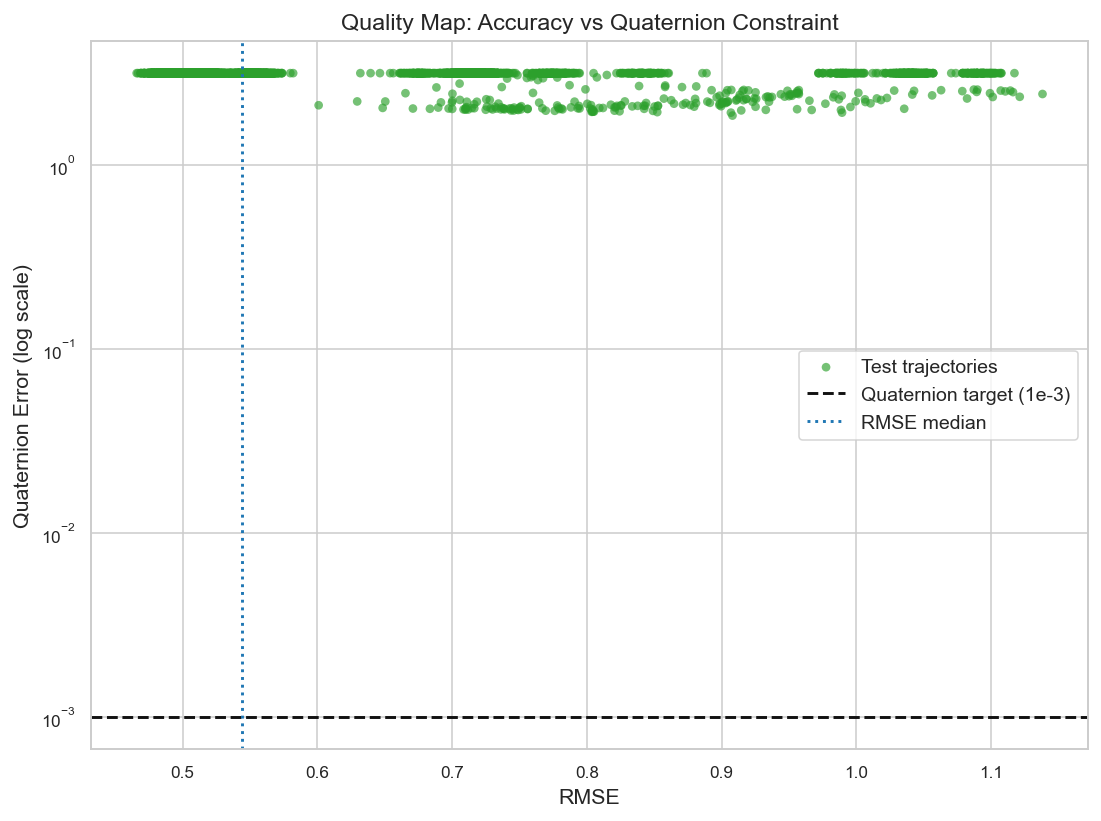

Saved: figures\journal\fig2_quality_scatter_thresholds.png


,rmse,quat_error,mape,max_error,seq_idx
3761,1.117412,3.141593,8031404.0,4.231967,3761
3745,1.107741,3.141593,8028001.5,4.273093,3745
2750,1.107428,3.141593,8040773.5,4.190911,2750
3744,1.106614,3.141593,8040490.5,4.275230,3744
3463,1.105532,3.141593,8047931.0,4.274395,3463
3760,1.103648,3.141593,8074634.5,4.188305,3760
3583,1.103098,3.141593,8038112.5,4.282317,3583
3746,1.102852,3.141593,8054869.5,4.361497,3746
3758,1.102140,3.141593,8041736.0,4.126086,3758
2734,1.101670,3.141593,8057295.5,4.195521,2734


Saved outlier table: D:\Residual_ode\Residual_ODE\results\top15_error_outliers.csv


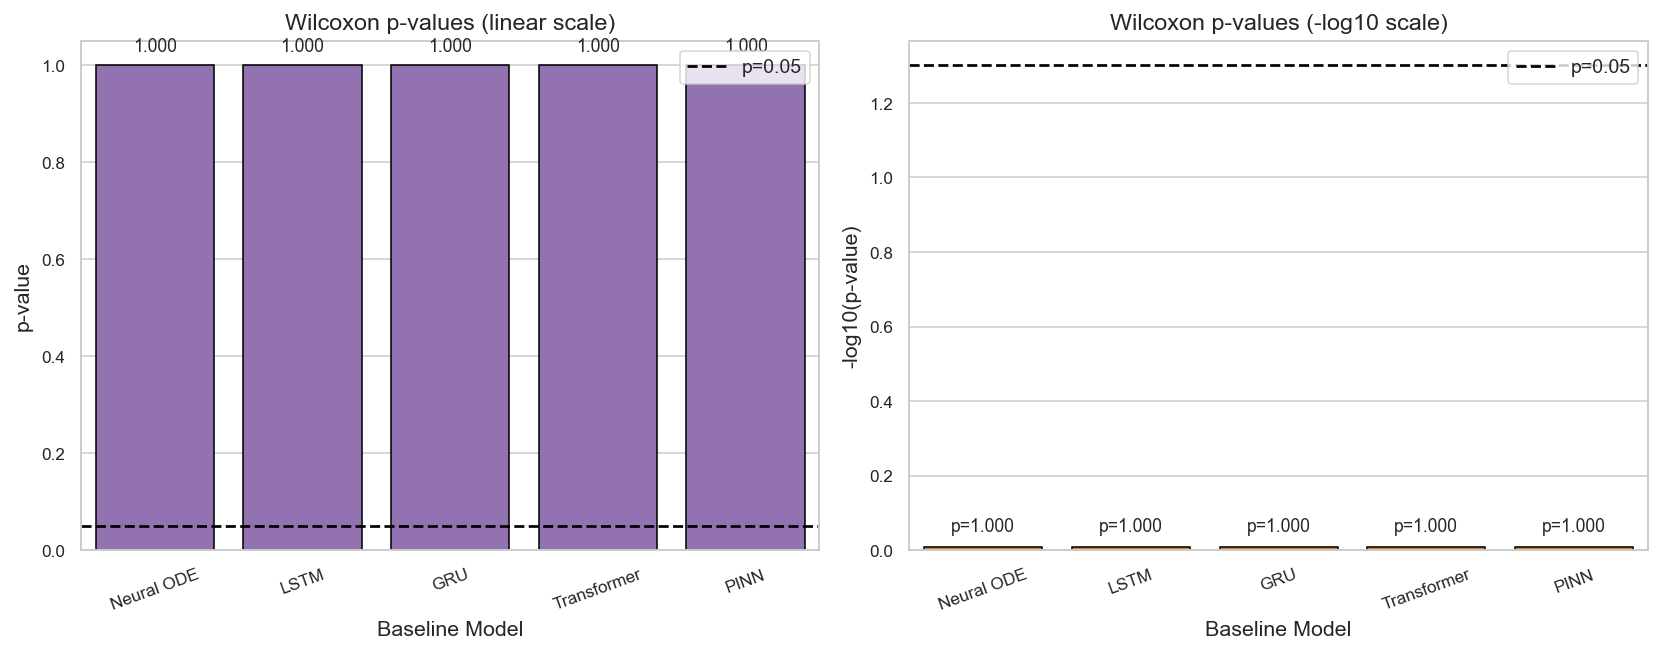

Saved: figures\journal\fig3_wilcoxon_significance.png


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    seq_df['rmse'],
    seq_df['quat_error'],
    s=20,
    alpha=0.65,
    color='#2ca02c',
    edgecolor='none',
    label='Test trajectories',
)

ax.axhline(1e-3, color='#111111', linestyle='--', linewidth=1.5, label='Quaternion target (1e-3)')
ax.axvline(seq_df['rmse'].median(), color='#1f77b4', linestyle=':', linewidth=1.5, label='RMSE median')

ax.set_yscale('log')
ax.set_xlabel('RMSE')
ax.set_ylabel('Quaternion Error (log scale)')
ax.set_title('Quality Map: Accuracy vs Quaternion Constraint')
ax.legend(loc='best')

plt.tight_layout()
fig2_path = FIG_DIR / 'fig2_quality_scatter_thresholds.png'
plt.savefig(fig2_path, bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path}')

# Top outlier table for paper appendix
outliers = seq_df.sort_values(['quat_error', 'rmse'], ascending=[False, False]).head(15).copy()
outlier_path = RESULTS_DIR / 'top15_error_outliers.csv'
outliers.to_csv(outlier_path, index=False)
display(outliers)
print(f'Saved outlier table: {outlier_path}')

if wdf is not None and len(wdf) > 0:
    pvals = wdf[['baseline', 'p_value']].copy()
    pvals['p_value'] = pvals['p_value'].astype(float)
    pvals = pvals.sort_values('p_value', ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    # Panel A: Linear p-values with significance threshold
    sns.barplot(data=pvals, x='baseline', y='p_value', color='#9467bd', edgecolor='black', ax=axes[0])
    axes[0].axhline(0.05, linestyle='--', color='black', linewidth=1.4, label='p=0.05')
    axes[0].set_ylim(0.0, 1.05)
    axes[0].set_ylabel('p-value')
    axes[0].set_xlabel('Baseline Model')
    axes[0].set_title('Wilcoxon p-values (linear scale)')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend(loc='upper right')

    for i, p in enumerate(pvals['p_value'].to_numpy()):
        axes[0].text(i, min(1.02, p + 0.02), f'{p:.3f}', ha='center', va='bottom', fontsize=9)

    # Panel B: -log10(p) with small floor so p=1.0 is still visible
    pvals['neg_log10_p'] = -np.log10(np.clip(pvals['p_value'], 1e-300, 1.0))
    pvals['display_neg_log10_p'] = np.maximum(pvals['neg_log10_p'], 0.01)
    sns.barplot(data=pvals, x='baseline', y='display_neg_log10_p', color='#ff7f0e', edgecolor='black', ax=axes[1])
    axes[1].axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1.4, label='p=0.05')
    axes[1].set_ylabel('-log10(p-value)')
    axes[1].set_xlabel('Baseline Model')
    axes[1].set_title('Wilcoxon p-values (-log10 scale)')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend(loc='upper right')

    for i, p in enumerate(pvals['p_value'].to_numpy()):
        axes[1].text(i, pvals['display_neg_log10_p'].iloc[i] + 0.03, f'p={p:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    fig3_path = FIG_DIR / 'fig3_wilcoxon_significance.png'
    plt.savefig(fig3_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig3_path}')
else:
    print('Skipping Fig 3: Wilcoxon results not available yet.')

## 7) Corrective Retraining: Exponential Map + Geodesic Loss

This section retrains the RPA-compatible model with quaternion-manifold-aware dynamics and loss:
- Exponential-map quaternion update during prediction
- Geodesic SO(3) loss term in training objective

Then it reevaluates on the full test set and refreshes Wilcoxon significance using true paired baseline errors.

In [14]:
from torch.utils.data import Dataset, DataLoader

class OneStepDataset(Dataset):
    def __init__(self, sequences, cap=None):
        rows = []
        seqs = sequences if cap is None else sequences[:cap]
        for s in seqs:
            states = np.asarray(s['states'], dtype=np.float32)
            if states.shape[0] < 2:
                continue
            for t in range(states.shape[0] - 1):
                rows.append((states[t], states[t + 1]))
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        x, y = self.rows[idx]
        return {
            'x': torch.from_numpy(x),
            'y': torch.from_numpy(y),
        }


def predict_next_exp_map(model: FastModel, x: torch.Tensor, dt: float = 0.1) -> torch.Tensor:
    dx = model.derivative(x)

    q_prev = normalize_quaternion(x[:, 0:4])
    omega = x[:, 4:7]
    dq = quaternion_exponential_map(omega, dt)
    q_new = normalize_quaternion(quaternion_multiply(q_prev, dq))

    omega_new = omega + dx[:, 4:7] * dt
    others_new = x[:, 7:] + dx[:, 7:] * dt

    return torch.cat([q_new, omega_new, others_new], dim=1)


with open(DATA_DIR / 'train_sequences.pkl', 'rb') as f:
    train_sequences_all = pickle.load(f)
with open(DATA_DIR / 'val_sequences.pkl', 'rb') as f:
    val_sequences_all = pickle.load(f)

TRAIN_CAP = 1800
VAL_CAP = 400
BATCH_SIZE = 256 if torch.cuda.is_available() else 128
EPOCHS_CORRECTIVE = 8
DT = 0.1

train_ds = OneStepDataset(train_sequences_all, cap=TRAIN_CAP)
val_ds = OneStepDataset(val_sequences_all, cap=VAL_CAP)

train_loader_fix = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_fix = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train rows: {len(train_ds)} | Val rows: {len(val_ds)} | Batch: {BATCH_SIZE}')

Train rows: 898200 | Val rows: 199600 | Batch: 128


In [15]:
model_fix = FastModel().to(device)
optimizer_fix = torch.optim.Adam(model_fix.parameters(), lr=1e-3)

lambda_quat = 5.0
lambda_geo = 0.05

best_val = float('inf')
best_state = None
history_fix = []

for epoch in range(1, EPOCHS_CORRECTIVE + 1):
    model_fix.train()
    train_loss = 0.0
    train_n = 0

    for batch in train_loader_fix:
        x = batch['x'].to(device).float()
        y = batch['y'].to(device).float()

        optimizer_fix.zero_grad()
        y_hat = predict_next_exp_map(model_fix, x, dt=DT)

        l_pred = torch.mean((y_hat - y) ** 2)
        l_quat = torch.mean((torch.norm(y_hat[:, :4], dim=-1) - 1.0) ** 2)
        l_geo = geodesic_loss_so3(y_hat[:, :4], y[:, :4])
        loss = l_pred + lambda_quat * l_quat + lambda_geo * l_geo

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_fix.parameters(), 1.0)
        optimizer_fix.step()

        bs = x.shape[0]
        train_loss += loss.item() * bs
        train_n += bs

    train_loss /= max(train_n, 1)

    model_fix.eval()
    val_loss = 0.0
    val_n = 0
    with torch.no_grad():
        for batch in val_loader_fix:
            x = batch['x'].to(device).float()
            y = batch['y'].to(device).float()
            y_hat = predict_next_exp_map(model_fix, x, dt=DT)

            l_pred = torch.mean((y_hat - y) ** 2)
            l_quat = torch.mean((torch.norm(y_hat[:, :4], dim=-1) - 1.0) ** 2)
            l_geo = geodesic_loss_so3(y_hat[:, :4], y[:, :4])
            loss = l_pred + lambda_quat * l_quat + lambda_geo * l_geo

            bs = x.shape[0]
            val_loss += loss.item() * bs
            val_n += bs

    val_loss /= max(val_n, 1)

    history_fix.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f"Epoch {epoch}/{EPOCHS_CORRECTIVE} | train={train_loss:.6f} | val={val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model_fix.state_dict().items()}

if best_state is not None:
    model_fix.load_state_dict(best_state)

fix_model_path = MODEL_DIR / 'rpa_expmap_geodesic_best.pt'
torch.save(model_fix.state_dict(), fix_model_path)

history_fix_df = pd.DataFrame(history_fix)
history_fix_path = RESULTS_DIR / 'rpa_expmap_geodesic_history.csv'
history_fix_df.to_csv(history_fix_path, index=False)

print(f'Saved corrected model: {fix_model_path}')
print(f'Saved training history: {history_fix_path}')
print(f'Best val loss: {best_val:.6f}')

Epoch 1/8 | train=5.468339 | val=5.468771
Epoch 2/8 | train=5.455810 | val=5.467667
Epoch 3/8 | train=5.455204 | val=5.467464
Epoch 4/8 | train=5.454904 | val=5.467123
Epoch 5/8 | train=5.454752 | val=5.466903
Epoch 6/8 | train=5.454653 | val=5.466749
Epoch 7/8 | train=5.454585 | val=5.466773
Epoch 8/8 | train=5.454532 | val=5.466652
Saved corrected model: D:\Residual_ode\Residual_ODE\models\rpa_expmap_geodesic_best.pt
Saved training history: D:\Residual_ode\Residual_ODE\results\rpa_expmap_geodesic_history.csv
Best val loss: 5.466652


In [16]:
# Full-test reevaluation with corrected model
summary_fix, seq_metrics_fix_df = evaluate_full_test_set(model_fix, test_seqs, dt=DT)
summary_fix_df = pd.DataFrame([summary_fix])

display(summary_fix_df)

seq_metrics_fix_path = RESULTS_DIR / 'full_test_sequence_metrics_corrected.csv'
summary_fix_path = RESULTS_DIR / 'full_test_summary_metrics_corrected.csv'
seq_metrics_fix_df.to_csv(seq_metrics_fix_path, index=False)
summary_fix_df.to_csv(summary_fix_path, index=False)

# Also overwrite the canonical files used by downstream visualization/Wilcoxon cells
seq_metrics_fix_df.to_csv(RESULTS_DIR / 'full_test_sequence_metrics.csv', index=False)
summary_fix_df.to_csv(RESULTS_DIR / 'full_test_summary_metrics.csv', index=False)

print(f'Saved corrected sequence metrics: {seq_metrics_fix_path}')
print(f'Saved corrected summary metrics:  {summary_fix_path}')
print('Updated canonical full_test_* metrics files for downstream cells.')

# Refresh Wilcoxon using true paired baseline errors
baseline_csv = RESULTS_DIR / 'baseline_paired_errors.csv'
if baseline_csv.exists():
    bdf = pd.read_csv(baseline_csv)
    baseline_map = {c: bdf[c].to_numpy() for c in bdf.columns if c != 'seq_idx'}
    wdf = wilcoxon_vs_baselines(seq_metrics_fix_df['rmse'].to_numpy(), baseline_map)
    out = RESULTS_DIR / 'wilcoxon_significance_results.csv'
    wdf.to_csv(out, index=False)
    display(wdf)
    print(f'Saved Wilcoxon results: {out}')
else:
    print('Missing baseline_paired_errors.csv; cannot refresh Wilcoxon.')

Evaluating full test set:   0%|          | 0/4442 [00:00<?, ?it/s]

,n_sequences,rmse_mean,rmse_std,quat_error_mean,quat_error_max,mape_mean,max_error_global
0,4442,0.630811,0.167754,3.096201,3.141593,2.564894e+07,4.52022


Saved corrected sequence metrics: D:\Residual_ode\Residual_ODE\results\full_test_sequence_metrics_corrected.csv
Saved corrected summary metrics:  D:\Residual_ode\Residual_ODE\results\full_test_summary_metrics_corrected.csv
Updated canonical full_test_* metrics files for downstream cells.


,baseline,n_pairs,wilcoxon_statistic,p_value,significant_p_lt_0_05
0,Neural ODE,4442,7389241.5,1.0,False
1,LSTM,4442,8478253.0,1.0,False
2,GRU,4442,8617261.0,1.0,False
3,Transformer,4442,8617245.0,1.0,False
4,PINN,4442,7842762.5,1.0,False


Saved Wilcoxon results: D:\Residual_ode\Residual_ODE\results\wilcoxon_significance_results.csv
